# Imports

In [1]:
import traceback
from src.equation_discovery.config_equations_for_each_dataset import ConfigEquationDiscovery
from src.equation_discovery.evaluate_equation import test_equation, map_equation_to_syntax_tree, evaluate_equation
from src.analyse_equations.analyse_equations import load_proposed_equations, add_proposed_equations, save_proposed_equation, system_data, all_data, get_train_test_files, proposed_equation_to_df, \
    add_units, plot_error_per_system, histogram_for_features, abs_difference_between_equation, add_propagate_error
from src.preprocess_data.preprocess_data import prepare_dataset, split_train_test, get_unit_dict
from src.analyse_equations.config_analyse_equations import ConfigPlotBestEquation
from src.preprocess_data.config_load_dataset import ConfigLoadData
from src.SyntaxTree.src.syntax_tree.config_syntax_tree import ConfigSyntaxTree
from src.utils.config_hyperparameter import ConfigHyperparameter
import pandas as pd

# Configs

In [2]:
parser =ConfigHyperparameter.arguments_parser()
parser= ConfigLoadData.arguments_parser(parser)
parser = ConfigEquationDiscovery.arguments_parser(parser)
parser = ConfigPlotBestEquation.arguments_parser(parser)
parser = ConfigSyntaxTree.arguments_parser(parser)
args = parser.parse_args()
args.save_path = args.ROOT_DIR /f'results/Xiaomei/equation_set_{args.equation_set_id}.json'
args.unit_dict = get_unit_dict(args)
args.unit_dict['y'] = args.unit_dict[args.target]
args.unit_dimension = 5
args.features= ['drop_length', 'adv', 'rec','avg_vel', 'width']
measurement_error_dic = {
    'drop_length': 0.5,
    'adv': 0.5,
    'rec': 0.5,
    'avg_vel': 0.5,
    'width': 0.5
}

# Results to load

In [3]:
proposed_equations = load_proposed_equations(args)
add_proposed_equations(args, proposed_equations)

# Dataset to load 

For the dataset: 125, 12-summary-Teflon -Au-70_Glyerol in water.xlsx, 25.0° 
    only 75.0 % of the records are used.
    the iqr is: 2.79E-06
For the dataset: 97, 12-summary-Teflon -Au-70_Glyerol in water.xlsx, 25.0° 
    only 75.0 % of the records are used.
    the iqr is: 2.79E-06


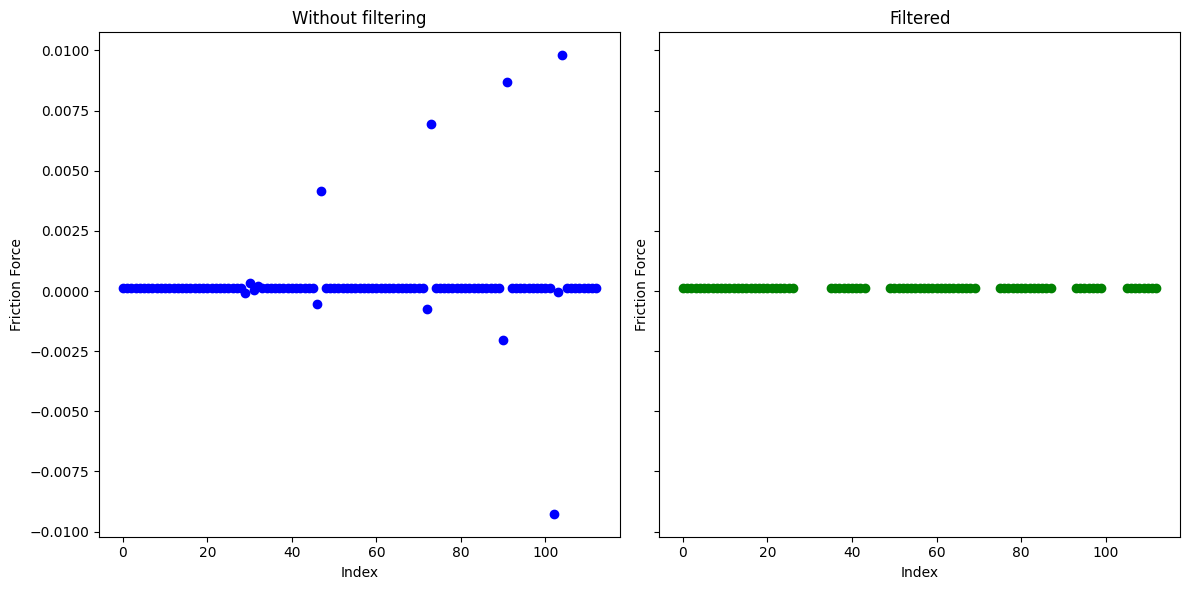

In [4]:
files_test, files_train = get_train_test_files(args, proposed_equations)
filtered_dfs_train = prepare_dataset(args, files_train)
filtered_dfs_test = prepare_dataset(args, files_test)

# Calculate Error over all data and per system 

In [5]:
equation_list = list(proposed_equations.keys())
for equation in equation_list:
    try:
        tree = all_data(args, equation, filtered_dfs_test, filtered_dfs_train, proposed_equations)
        system_data(args, equation, filtered_dfs_test, proposed_equations, tree)
        add_units(args, equation, filtered_dfs_train, proposed_equations, tree)
        add_propagate_error(args, equation, filtered_dfs_test, measurement_error_dic, proposed_equations, tree)

    except Exception as e:
        del proposed_equations[equation]
        print(traceback.format_exc())
        print(e)

Error in error propagation  Sympify of expression 'could not parse '( ( 8.84e-05 * (  ( adv )  -  ( rec )  )  )  *  exp  sin (  ( rec )  ) ) '' failed, because of exception being raised:
SyntaxError: invalid syntax. Perhaps you forgot a comma? (<string>, line 1)
original equation : ( ( 8.84e-05 * (  ( adv )  -  ( rec )  )  )  *  exp  sin (  ( rec )  ) ) 
derivative target : drop_length
ValueError: Error from parse_expr with transformed code: "((Float ('8.84e-05' )*((Symbol ('adv' ))-(Symbol ('rec' ))))*exp sin ((Symbol ('rec' ))))"

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/jbrugger/PycharmProjects/venv_Robot_Scientist/lib/python3.10/site-packages/sympy/core/sympify.py", line 481, in sympify
    expr = parse_expr(a, local_dict=locals, transformations=transformations, evaluate=evaluate)
  File "/home/jbrugger/PycharmProjects/venv_Robot_Scientist/lib/python3.10/site-packages/sympy/parsing/sympy_parser.py", line 

# Save proposed equation 

In [6]:
save_proposed_equation(args, files_test, files_train, proposed_equations)

Proposed Equations are saved to: /home/jbrugger/PycharmProjects/EquatationDiscoveryDropFriction/results/Xiaomei/equation_set_01_March.json


# Equations sorted after validation error 

In [7]:
num_variables = 1
pd.options.display.float_format = '${:.2e}'.format
df = proposed_equation_to_df(proposed_equations, num_variables)
df

,equation,infix,test all error,train all error,std
0,* c * drop_length ** adv 2,( c_0 * ( ( drop_length ) * ( adv ) ** ...,$1.55e-07,$1.11e-08,$1.34e-02
1,* c * adv drop_length,( c_0 * ( ( adv ) * ( drop_length ) ) ),$1.55e-07,$1.12e-08,$1.22e-02
2,* c ** adv 2,( c_0 * ( adv ) ** ( 2 ) ),$1.54e-07,$1.13e-08,$7.41e-05
3,* c adv,( c_0 * ( adv ) ),$1.55e-07,$1.14e-08,$3.45e-05
4,c,c_0,$1.55e-07,$1.16e-08,$0.00e+00
...,...,...,...,...,...
149,* c * - adv rec / sin rec drop_length,( c_0 * ( ( ( adv ) - ( rec ) ) * ( sin ...,$1.53e-07,$1.03e-08,$1.62e-02
150,* c ** cos / rec adv 3,( c_0 * cos (( ( rec ) / ( adv ) ) ) ...,$1.53e-07,$1.03e-08,$1.71e-04
151,* c * adv / 1 * rec ** adv 2,( c_0 * ( ( adv ) * ( ( 1 ) / ( ( rec ) ...,$1.54e-07,$1.10e-08,$3.42e-04
152,* c / 1 * rec ** ** adv 2 2,( c_0 * ( ( 1 ) / ( ( rec ) * ( adv )...,$1.55e-07,$1.21e-08,$4.77e-03


# Analyse one equation 

In [8]:
index = 24
equation=proposed_equations[df.iloc[index].loc['equation']]
equation_prefix = df.iloc[index].loc['equation']
tree = map_equation_to_syntax_tree(args, equation_prefix, infix=False, catch_exceptions=False)
for id , units in equation['units'].items():
    i = float(id.split('_')[0])
tree.constants_in_tree = proposed_equations[equation_prefix]['train_all']['constants']
add_units(args, equation_prefix, filtered_dfs_train, proposed_equations, tree)
print(tree.rearrange_equation_infix_notation())
tree.print()

('y', '( ( c_0 * (  ( adv )  -  ( rec )  )  )  /  ( width )  ) ')
d: 0  id: 0.0   /	 [1.0, -2.0, 1.0, 0.0, 0.0]
d: 1  id: 1.0   	*	 [2.0, -2.0, 1.0, 0.0, 0.0]
d: 2  id: 2.0   		c_0	 [2.0, -2.0, 1.0, 0.0, 0.0]
d: 2  id: 257.0 		-	 [0.0, 0.0, 0.0, 0.0, 0.0]
d: 3  id: 258.0 			adv	 [0. 0. 0. 0. 0.]
d: 3  id: 385.0 			rec	 [0. 0. 0. 0. 0.]
d: 1  id: 512.0 	width	 [1. 0. 0. 0. 0.]


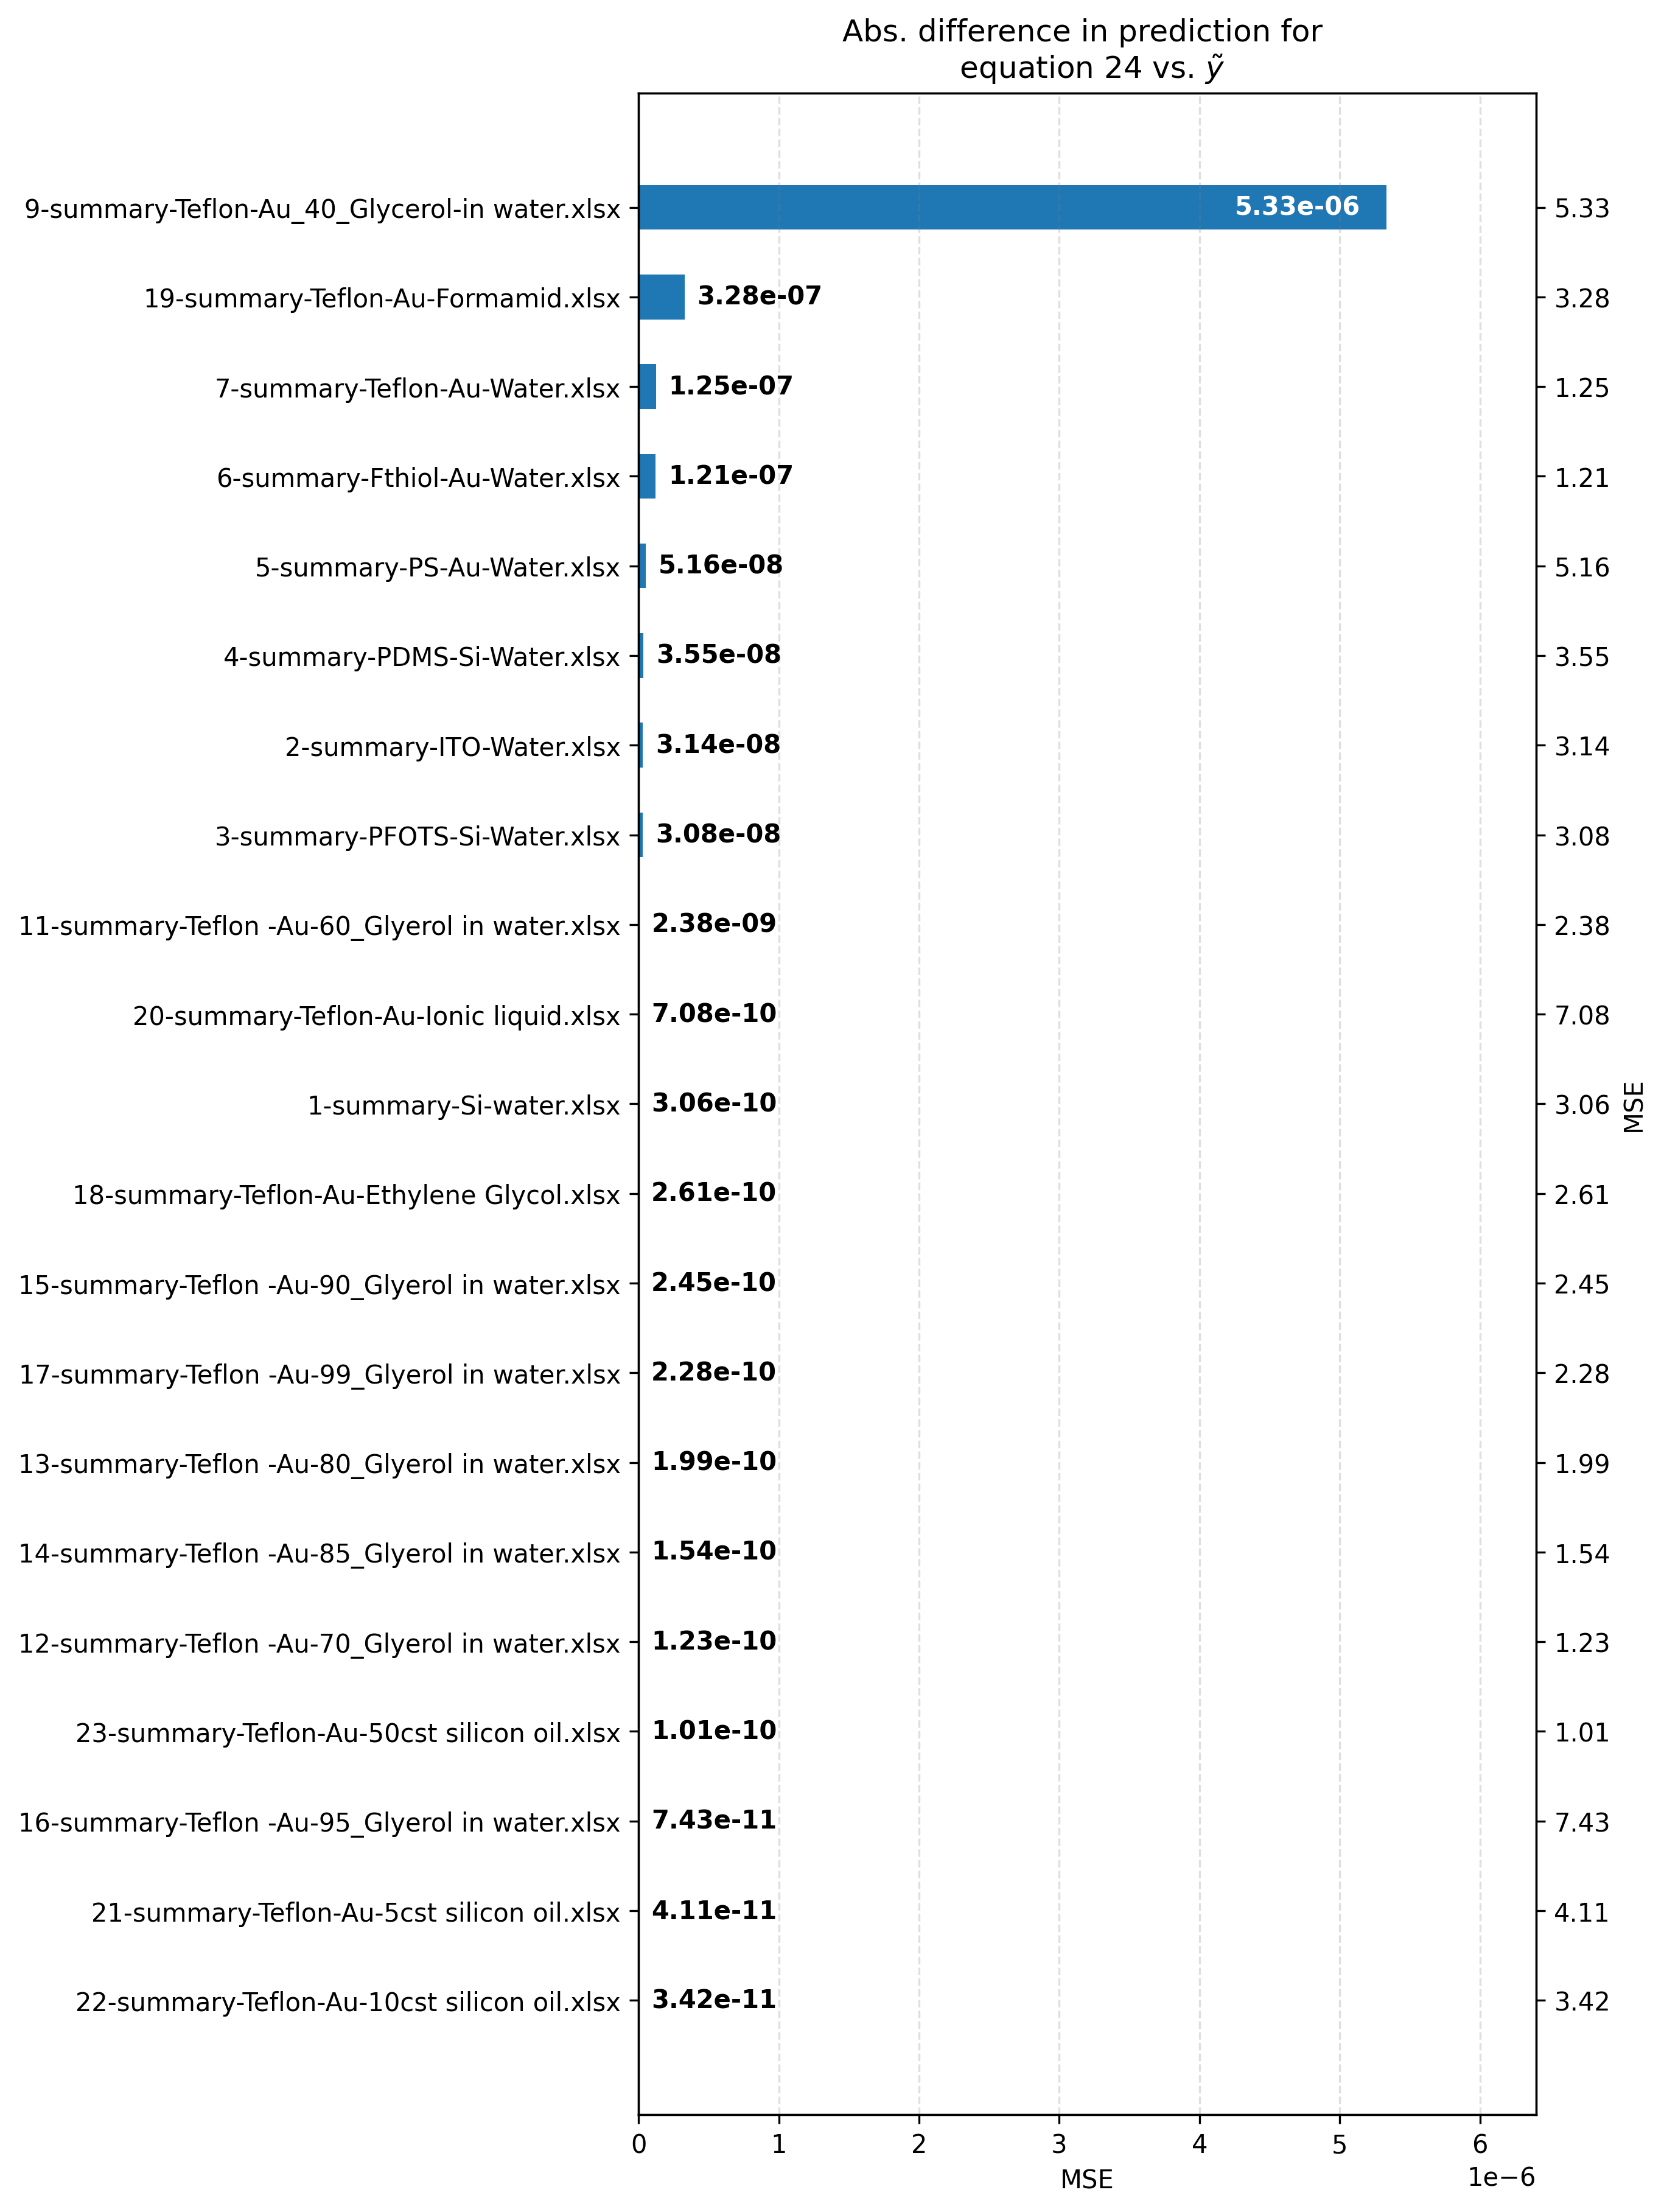

In [9]:
plot_error_per_system(args,df, index, proposed_equations) 

# Analyse Feature 

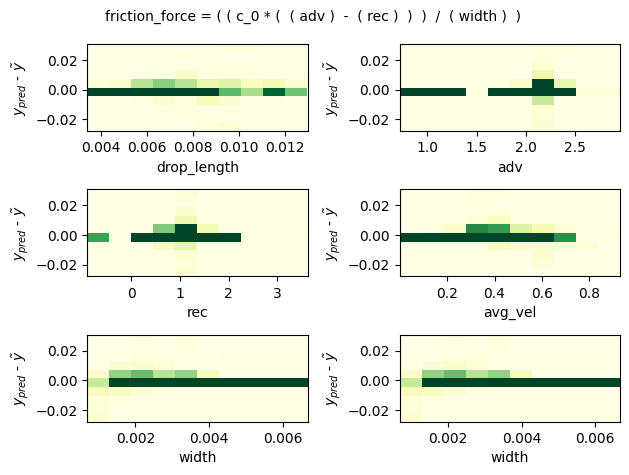

In [10]:
from src.analyse_equations.analyse_equations import  histogram_for_features
histogram_for_features(args, filtered_dfs_test, tree)

# Compare two equations

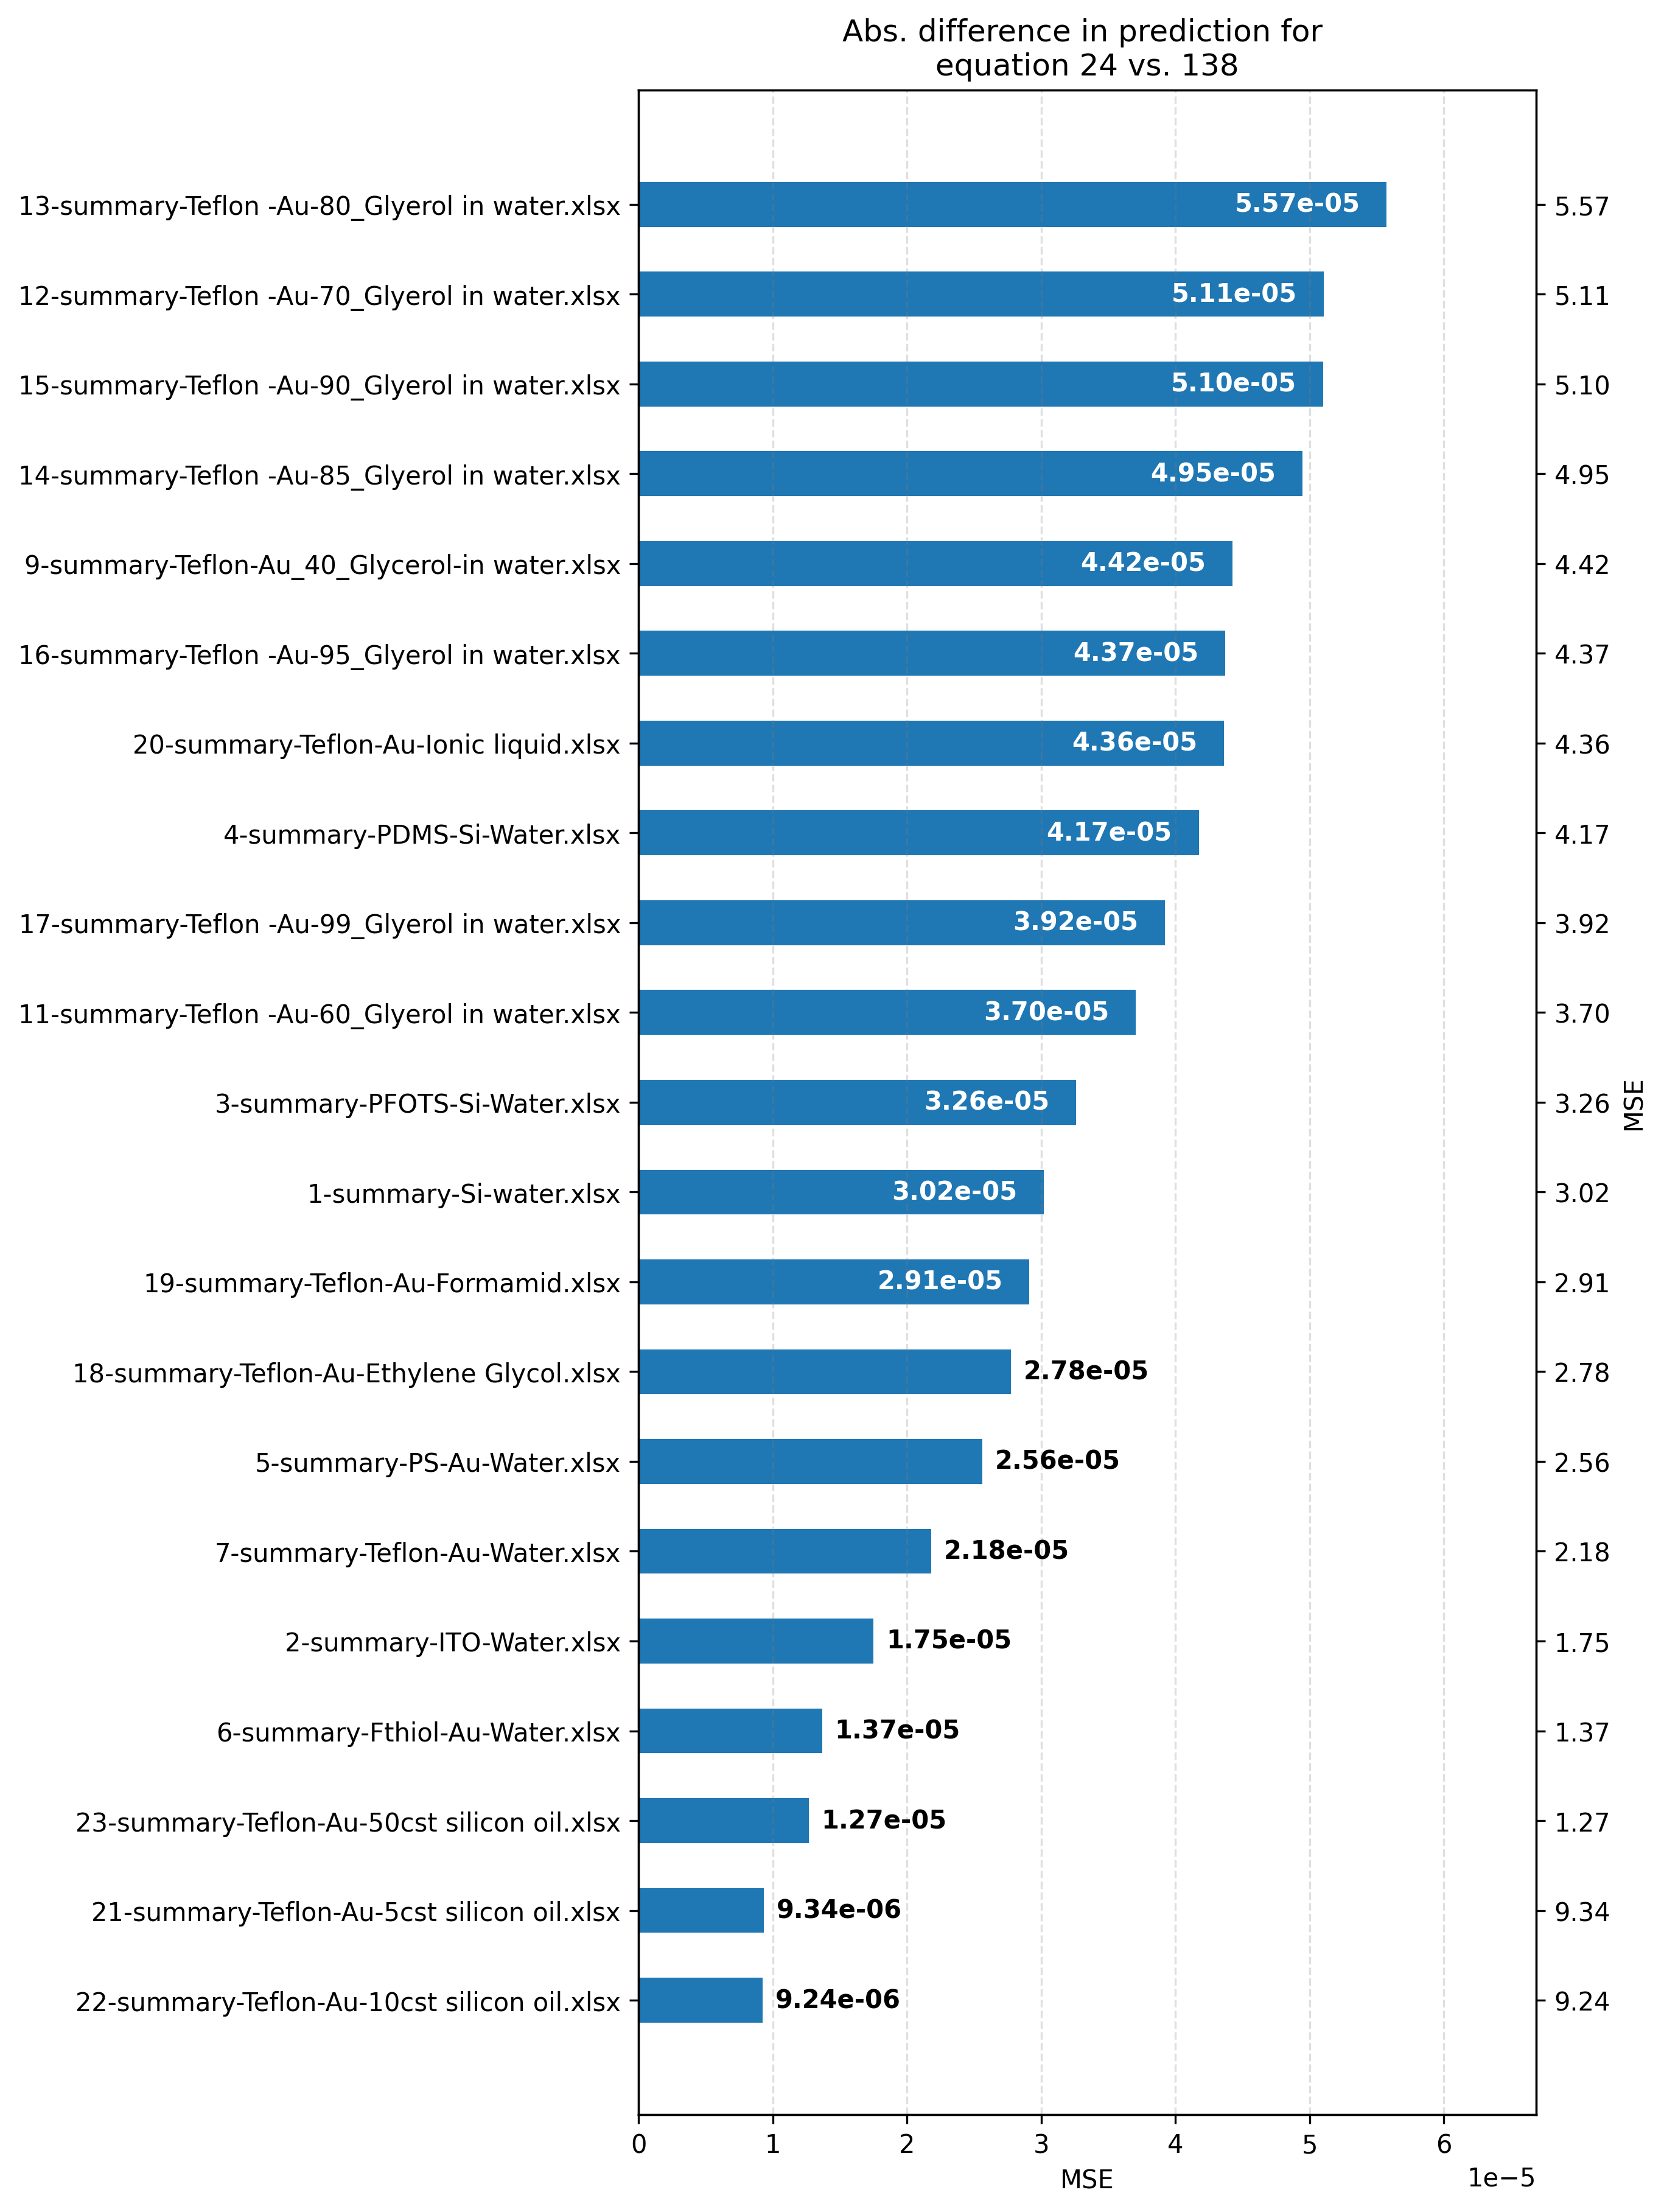

In [11]:
index_0 = 24
index_1 = 138
abs_difference_between_equation(args, proposed_equations, df, filtered_dfs_test, index_0, index_1)
